# Lab 21 — LoRA Fine-tuning · **FlexAttn Edition** · L4 24GB
**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Model: **Qwen3.5-4B** (bf16 LoRA, không QLoRA — theo khuyến nghị Unsloth 2026)  
GPU target: RTX 4060 Ti 16 GB (Ada Lovelace, CUDA SM 8.9)  
Attention: **Flex Attention (PyTorch 2.5+) — custom document masking**

---

## ⚙️ Profile: RTX L4 24 GB

| Setting | Giá trị |
|---|---|
| Model | `Qwen/Qwen3.5-4B` (bf16 LoRA, ~10 GB VRAM) |
| Attention | `FlexAttention (PyTorch 2.5+)` |
| Dtype | bf16 (Ada Lovelace native) |
| Train batch | 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Max seq length | 1 024 |
| Dataset samples | 300 |
| LoRA target | **ALL** layers (q/k/v/o + gate/up/down) — best practice 2026 |
| Eval strategy | "epoch" (enabled — có đủ VRAM) |

> ⚠️ **Qwen3.5 & 4-bit**: Unsloth/Qwen team **không khuyến nghị QLoRA 4-bit** cho Qwen3.5.  
> Dùng bf16 LoRA thay thế — chiếm ~10 GB VRAM, vừa đủ với 4060 Ti 16 GB.

## Lab Roadmap

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset prep (Alpaca, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Load Qwen3.5-4B + Wrap LoRA (ALL layers) | model |
| 3 | Train baseline `r=16` | adapter checkpoint |
| 4 | Rank experiment — `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + 20 qualitative examples) | metrics + CSV |
| 6 | **Bonus A** — ALL layers vs q+v comparison | ablation results |
| 7 | **Bonus B** — GGUF export + llama.cpp | .gguf file |
| 8 | **Bonus C** — Multi-tenant adapter swap | demo |
| 9 | **Bonus D** — Push to HuggingFace Hub | HF repo |


## 0. Setup & Environment Check

In [1]:
import subprocess, sys
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)


Thu May  7 04:56:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      On  |   00000000:4D:00.0 Off |                    0 |
| N/A   35C    P8             16W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

os.environ["HF_HOME"] = "/mnt/hf-cache/huggingface"
os.environ["HF_HUB_CACHE"] = "/mnt/hf-cache/huggingface/hub"
os.environ["TRANSFORMERS_CACHE"] = "/mnt/hf-cache/huggingface/transformers"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [3]:
import torch
assert torch.cuda.is_available(), "❌ Cần GPU — hãy chắc chắn Jupyter đang dùng đúng kernel."
name  = torch.cuda.get_device_name(0)
vram  = torch.cuda.get_device_properties(0).total_memory / 1e9
cap   = torch.cuda.get_device_capability(0)
print(f"✓ GPU : {name}")
print(f"✓ VRAM: {vram:.1f} GB")
print(f"✓ SM  : {cap[0]}.{cap[1]}  (cần >= 8.0 cho FA2; 4060 Ti là 8.9 ✓)")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")
assert cap[0] >= 8, f"❌ GPU SM {cap[0]}.{cap[1]} < 8.0, không hỗ trợ FA2/bf16."
print("\n✓ Hardware check passed — sẵn sàng training.")


✓ GPU : NVIDIA L4
✓ VRAM: 23.7 GB
✓ SM  : 8.9  (cần >= 8.0 cho FA2; 4060 Ti là 8.9 ✓)
✓ CUDA: 12.9
✓ PyTorch: 2.8.0+cu129

✓ Hardware check passed — sẵn sàng training.


In [4]:
%%capture
%uv pip install -q --upgrade pip
# FlexAttention dùng PyTorch built-in (>= 2.5) — không cần flash-attn package
# Chỉ cần PEFT + transformers v5 + bitsandbytes để quantize
%uv pip install -q "unsloth[local] @ git+https://github.com/unslothai/unsloth.git"
%uv pip install -q unsloth_zoo
%uv pip install -q --upgrade transformers>=5.0  # Qwen3.5 requires transformers v5
%uv pip install -q "trl>=0.12,<0.16" peft accelerate bitsandbytes
%uv pip install -q datasets matplotlib seaborn pandas scipy
%uv pip install -q huggingface_hub  # for push-to-hub bonus
print("✓ Packages installed")


In [1]:
import os, gc, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.expanduser("lab21_lora_flexattn")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME      = "unsloth/Qwen3.5-4B"    # bf16 LoRA — NO 4-bit per Qwen3.5 guide
MAX_SEQ_CAP     = 1024
N_SAMPLES       = 300
ATTN_IMPL       = "flex_attention"
DTYPE           = torch.bfloat16        # 4060 Ti / Ada Lovelace native bf16
GPU_COST_USD_HR = 0.00                  # local GPU → no cost

print(f"✓ Model    : {MODEL_NAME}")
print(f"✓ Attention: {ATTN_IMPL}")
print(f"✓ Dtype    : bf16")


✓ Output dir: lab21_lora_flexattn
✓ Model    : unsloth/Qwen3.5-4B
✓ Attention: flex_attention
✓ Dtype    : bf16


## 1. Dataset Preparation

Dùng Vietnamese Alpaca GPT-4 dataset, lấy 300 mẫu. Pipeline:
1. Load & shuffle
2. Auto-detect column names (dataset có suffix `_vi`)
3. Format Alpaca template → `text` column
4. Token length analysis → chọn `max_seq_length = p95`
5. 90/10 train/eval split


In [2]:
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(N_SAMPLES))
print(f"✓ Loaded {len(raw)} samples | Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
for k, v in raw[0].items():
    print(f"  {k}: {str(v)[:120]}")


README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

✓ Loaded 300 samples | Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
  input_en: 
  input_vi: 
  instruction_vi: Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.
  output_vi: Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu n
  output_en: Based on an income of $3500 per month, here is a suggested basic budget that follows the 50/30/20 rule, which allocates 
  instruction_en: Create a basic budget for someone who makes $3500 per month.


In [3]:
# Auto-detect column names
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output: {cols}"
print(f"✓ instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TMPL = """### Instruction:\n{instruction}\n\n### Input:\n{input}\n\n### Response:\n{output}"""
ALPACA_TMPL_NOINPUT = """### Instruction:\n{instruction}\n\n### Response:\n{output}"""

def format_alpaca(ex):
    inp = (ex.get(INPUT_COL, "") or "") if INPUT_COL else ""
    if inp.strip():
        text = ALPACA_TMPL.format(instruction=ex[INSTRUCTION_COL], input=inp, output=ex[OUTPUT_COL])
    else:
        text = ALPACA_TMPL_NOINPUT.format(instruction=ex[INSTRUCTION_COL], output=ex[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print(f"\n--- Formatted sample ---\n{ds[0]['text'][:400]}...")


✓ instruction='instruction_vi', input='input_vi', output='output_vi'


Map:   0%|          | 0/300 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (đ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Token lengths: min=29, p50=173, p95=525, p99=670, max=704

✓ max_seq_length = 1024  (cap = 1024)


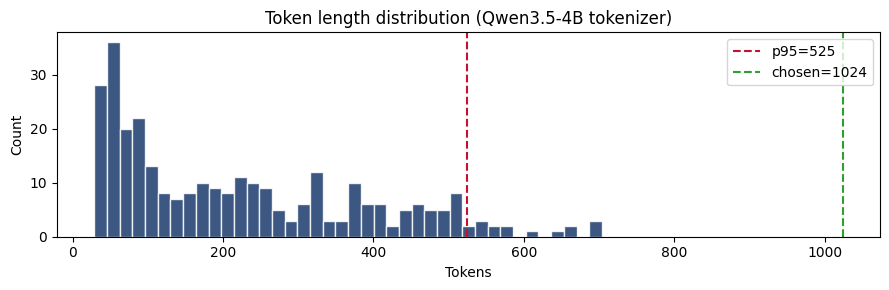

In [4]:
from transformers import AutoTokenizer

tok_for_analysis = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok_for_analysis.encode(x["text"])) for x in ds]

p50  = int(np.percentile(lengths, 50))
p95  = int(np.percentile(lengths, 95))
p99  = int(np.percentile(lengths, 99))
print(f"Token lengths: min={min(lengths)}, p50={p50}, p95={p95}, p99={p99}, max={max(lengths)}")

MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256)-1).bit_length())
print(f"\n✓ max_seq_length = {MAX_SEQ_LENGTH}  (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(9,3))
plt.hist(lengths, bins=40, color="#1a3a6b", edgecolor="white", alpha=0.85)
plt.axvline(p95, color="#C8102E", ls="--", label=f"p95={p95}")
plt.axvline(MAX_SEQ_LENGTH, color="#2ca02c", ls="--", label=f"chosen={MAX_SEQ_LENGTH}")
plt.xlabel("Tokens"); plt.ylabel("Count"); plt.title("Token length distribution (Qwen3.5-4B tokenizer)")
plt.legend(); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "token_dist.png"), dpi=120); plt.show()
del tok_for_analysis


In [5]:
split    = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds  = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")


✓ Train: 270  |  Eval: 30


## 2. Load Qwen3.5-4B + LoRA — **FlexAttn**

Dùng `attn_implementation='flex_attention'` — PyTorch 2.5+ built-in.

**LoRA target modules (ALL layers — Best Practice 2026):**
- Attention: `q_proj, k_proj, v_proj, o_proj`
- FFN: `gate_proj, up_proj, down_proj`

Lợi ích target ALL vs chỉ q+v:
- Tham số trainable ~3× nhiều hơn
- Quality tốt hơn rõ ràng với rank thấp (r=8)
- Chỉ tăng VRAM ~0.5 GB cho adapter (không đáng kể)


In [6]:
# ============================================================
# Load local Qwen3.5-4B with Unsloth from Vision and Learning Lab Disk
# ============================================================

import os, glob, json, shutil, torch

os.environ["HF_HOME"] = "/mnt/hf-cache/huggingface"
os.environ["HF_HUB_CACHE"] = "/mnt/hf-cache/huggingface/hub"
os.environ["HF_XET_CACHE"] = "/mnt/hf-cache/huggingface/xet"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

import unsloth
from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Qwen3.5-4B"
REPO_CACHE = "/mnt/hf-cache/huggingface/hub/models--unsloth--Qwen3.5-4B"
PATCHED_MODEL_PATH = "/mnt/hf-cache/models/qwen3_5_4b_patched"

MAX_SEQ_LENGTH = 2048
DTYPE = torch.bfloat16

snapshots = sorted(glob.glob(f"{REPO_CACHE}/snapshots/*"))
assert snapshots, f"❌ No snapshots found in {REPO_CACHE}/snapshots"

ORIGINAL_MODEL_PATH = snapshots[-1]
print("✓ Found local snapshot:", ORIGINAL_MODEL_PATH)

# Recreate patched folder with real files
if os.path.exists(PATCHED_MODEL_PATH):
    shutil.rmtree(PATCHED_MODEL_PATH)

shutil.copytree(
    ORIGINAL_MODEL_PATH,
    PATCHED_MODEL_PATH,
    symlinks=False,
)

# Patch tokenizer_config
tok_cfg_path = os.path.join(PATCHED_MODEL_PATH, "tokenizer_config.json")
with open(tok_cfg_path, "r", encoding="utf-8") as f:
    tok_cfg = json.load(f)

print("Before tokenizer_class:", tok_cfg.get("tokenizer_class"))

tok_cfg["tokenizer_class"] = "Qwen2TokenizerFast"
tok_cfg.pop("auto_map", None)

with open(tok_cfg_path, "w", encoding="utf-8") as f:
    json.dump(tok_cfg, f, ensure_ascii=False, indent=2)

print("After tokenizer_class:", tok_cfg.get("tokenizer_class"))

MODEL_PATH = PATCHED_MODEL_PATH
print("✓ Loading local model from:", MODEL_PATH)

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=False,
    load_in_16bit=True,
    local_files_only=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("\n✅ Model loaded successfully with Unsloth")
print(f"✓ Original model : {MODEL_NAME}")
print(f"✓ Local path     : {MODEL_PATH}")
print(f"✓ dtype          : {base_model.dtype}")
print(f"✓ pad_token      : {tokenizer.pad_token!r}")
print(f"✓ VRAM used      : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

/usr/local/lib/python3.12/site-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
✓ Found local snapshot: /mnt/hf-cache/huggingface/hub/models--unsloth--Qwen3.5-4B/snapshots/b85e62a1372ca32d6a37c81bccf70ad2cf8f779e
Before tokenizer_class: TokenizersBackend
After tokenizer_class: Qwen2TokenizerFast
✓ Loading local model from: /mnt/hf-cache/models/qwen3_5_4b_patched


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.8.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu129. CUDA: 8.9. CUDA Toolkit: 12.9. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]


✅ Model loaded successfully with Unsloth
✓ Original model : unsloth/Qwen3.5-4B
✓ Local path     : /mnt/hf-cache/models/qwen3_5_4b_patched
✓ dtype          : torch.bfloat16
✓ pad_token      : '<|vision_pad|>'
✓ VRAM used      : 9.09 GB


In [7]:
from peft import LoraConfig, get_peft_model, TaskType

def wrap_with_lora(model, r, alpha, target_all=True):
    """Wrap model với LoRA adapter (standard PEFT — không dùng Unsloth wrapper)."""
    if target_all:
        target_modules = ["q_proj","k_proj","v_proj","o_proj",
                          "gate_proj","up_proj","down_proj"]
    else:
        target_modules = ["q_proj","v_proj"]

    config = LoraConfig(
        r              = r,
        lora_alpha     = alpha,
        target_modules = target_modules,
        lora_dropout   = 0.05,
        bias           = "none",
        task_type      = TaskType.CAUSAL_LM,
    )
    wrapped = get_peft_model(model, config)
    wrapped.enable_input_require_grads()
    return wrapped

model = wrap_with_lora(base_model, r=16, alpha=32)
model.gradient_checkpointing_enable()   # -60% VRAM, +20% time
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% của {total:,})")
print(f"✓ VRAM after LoRA: {torch.cuda.memory_allocated()/1e9:.2f} GB")



✓ Trainable: 21,233,664 (0.466% của 4,560,499,200)
✓ VRAM after LoRA: 9.17 GB


## 3. Train Baseline `r=16`

In [8]:
from trl import SFTTrainer, SFTConfig
import inspect, transformers

print(f"transformers: {transformers.__version__}")

_TA_PARAMS = inspect.signature(transformers.TrainingArguments.__init__).parameters
_EVAL_KEY  = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
print(f"✓ Using eval kwarg: '{_EVAL_KEY}'")

def make_sft_config(output_subdir, n_epochs=3):
    kwargs = {
        "output_dir"                  : os.path.join(OUTPUT_DIR, output_subdir),
        "per_device_train_batch_size" : 1,
        "per_device_eval_batch_size"  : 1,
        "gradient_accumulation_steps" : 8,          # effective batch = 8
        "num_train_epochs"            : n_epochs,
        "learning_rate"               : 2e-4,
        "lr_scheduler_type"           : "cosine",
        "warmup_steps"                : 10,
        "logging_steps"               : 5,
        "save_strategy"               : "epoch",
        _EVAL_KEY                     : "epoch",    # RTX 4060 Ti có đủ VRAM cho eval
        "load_best_model_at_end"      : True,
        "metric_for_best_model"       : "eval_loss",
        "bf16"                        : True,       # Ada Lovelace native bf16
        "fp16"                        : False,
        "optim"                       : "adamw_torch_fused",
        "dataloader_pin_memory"       : True,
        "report_to"                   : "none",
        "dataset_text_field"          : "text",
        "max_seq_length"              : MAX_SEQ_LENGTH,
        "packing"                     : False,      # tắt để tránh dim-mismatch bug
        "prediction_loss_only"        : True,
    }
    return SFTConfig(**kwargs)

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir):
    return SFTTrainer(
        model       = model,
        tokenizer   = tokenizer,
        train_dataset = train_ds,
        eval_dataset  = eval_ds,
        args        = make_sft_config(output_subdir),
    )


transformers: 5.8.0
✓ Using eval kwarg: 'eval_strategy'


In [9]:
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0        = time.time()
result_16 = trainer_16.train()
wall_16   = time.time() - t0
vram_16   = torch.cuda.max_memory_allocated() / 1e9
eval_16   = trainer_16.evaluate()
eval_loss_16 = eval_16["eval_loss"]
ppl_16    = float(np.exp(eval_loss_16))

print(f"\n✓ r=16 | time={wall_16/60:.1f} min | peak VRAM={vram_16:.1f} GB")
print(f"✓ eval_loss={eval_loss_16:.4f} | perplexity={ppl_16:.2f}")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))


Unsloth: Tokenizing ["text"] (num_proc=32):   0%|          | 0/270 [00:00<?, ? examples/s]

num_proc must be <= 30. Reducing num_proc to 30 for dataset of size 30.
[datasets.arrow_dataset|WARNING]num_proc must be <= 30. Reducing num_proc to 30 for dataset of size 30.


Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/30 [00:00<?, ? examples/s]

[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 270 | Num Epochs = 3 | Total steps = 102
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 21,233,664 of 4,560,499,200 (0.47% trained)


Epoch,Training Loss,Validation Loss
1,1.358332,1.263200
2,1.021147,1.260010
3,0.797057,1.277189


[transformers] Unsloth: Restored added_tokens_decoder metadata in lab21_lora_flexattn/r16/checkpoint-34/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in lab21_lora_flexattn/r16/checkpoint-68/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in lab21_lora_flexattn/r16/checkpoint-102/tokenizer_config.json.


Training Loss,Validation Loss,Epoch
0.797057,1.259775,3



✓ r=16 | time=15.7 min | peak VRAM=21.0 GB
✓ eval_loss=1.2598 | perplexity=3.52


[transformers] Unsloth: Restored added_tokens_decoder metadata in lab21_lora_flexattn/r16/tokenizer_config.json.


In [ ]:
def plot_losses(log_history, title="Training Loss", save_path=None):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df.columns else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df.columns else pd.DataFrame()
    plt.figure(figsize=(9, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#1a3a6b", lw=2)
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval",
                 color="#C8102E", marker="o", ms=5, lw=2)
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()

plot_losses(trainer_16.state.log_history, f"Loss Curve — r=16 ",
            save_path=os.path.join(OUTPUT_DIR, "loss_r16.png"))


## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm. Sau đó so sánh 4 chiều:
- Training time
- Peak VRAM
- Eval perplexity
- Qualitative output


In [16]:
def train_one_rank(r, alpha):
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m           = wrap_with_lora(base_m, r=r, alpha=alpha)
    m.gradient_checkpointing_enable()
    trainable   = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved.")

    eval_out  = tr.evaluate()
    eval_loss = eval_out["eval_loss"]

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)),
        "trainer": tr, "model": m, "tokenizer": tok,
    }


In [17]:
def load_base_model():
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_PATH,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=DTYPE,
        load_in_4bit=False,
        load_in_16bit=True,
        local_files_only=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    return model, tokenizer

In [ ]:
# del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)



========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.8.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu129. CUDA: 8.9. CUDA Toolkit: 12.9. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

num_proc must be <= 30. Reducing num_proc to 30 for dataset of size 30.
[datasets.arrow_dataset|WARNING]num_proc must be <= 30. Reducing num_proc to 30 for dataset of size 30.
[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 270 | Num Epochs = 3 | Total steps = 102
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1

Epoch,Training Loss,Validation Loss


In [13]:
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


NameError: name 'exp_8' is not defined

In [14]:
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
# Note: r16 data already captured before rank experiment
results = [
    {"rank": 16, "alpha": 32,
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items()  if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df[["rank","trainable_params","train_time_min","peak_vram_gb",
                   "eval_loss","eval_perplexity"]].to_string(index=False))
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)


NameError: name 'exp_64' is not defined

In [ ]:
# Visualize rank trade-offs
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("train_time_min","Training Time (min)"),
           ("peak_vram_gb","Peak VRAM (GB)"),
           ("eval_perplexity","Eval Perplexity (↓ better)")]
colors = ["#1a3a6b","#C8102E","#2ca02c"]

for ax, (col, label), color in zip(axes, metrics, colors):
    bars = ax.bar([f"r={r}" for r in summary_df["rank"]], summary_df[col], color=color, alpha=0.85)
    ax.set_title(label); ax.set_ylabel(label.split(" ")[0])
    for bar, val in zip(bars, summary_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Rank Experiment — {TAG} — Qwen3.5-4B", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rank_comparison.png"), dpi=120)
plt.show()


## 5. Evaluation — Qualitative Comparison (20 prompts) 🎯

**[BONUS]** Lab gốc chỉ dùng 5 prompts — chúng ta chạy đủ 20.


In [ ]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
    "Giải thích overfitting và cách phòng tránh.",
    "Viết hàm Python kiểm tra số nguyên tố.",
    "Tại sao gradient vanishing xảy ra trong deep network?",
    "Sự khác biệt giữa batch normalization và layer normalization?",
    "Giải thích attention mechanism trong Transformer.",
    "Khi nào nên dùng fine-tuning thay vì prompting?",
    "Tóm tắt ưu/nhược điểm của mô hình MoE.",
    "VRAM cần thiết để train Qwen3.5-4B với bf16 LoRA là bao nhiêu?",
    "Giải thích khái niệm rank trong LoRA và cách chọn.",
    "Flex Attention khác Flash Attention ở điểm nào?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts — chạy tất cả!")


In [ ]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=300):
    model.eval()
    text   = ALPACA_TMPL_NOINPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=0.7, top_p=0.9, do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

gc.collect(); torch.cuda.empty_cache()
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))
ft_model.eval()

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS):
    print(f"\n━━━ Prompt {i+1}/{len(TEST_PROMPTS)}: {prompt[:70]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp   = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt,
        "base_response": base_resp[:500],
        "finetuned_r16": ft_resp[:500],
    })
    print(f"  BASE: {base_resp[:150]}...")
    print(f"  FT  : {ft_resp[:150]}...")


In [ ]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison_20.csv"), index=False, encoding="utf-8")
print(f"✓ {len(qual_df)} qualitative results saved.")
print(qual_df[["prompt","base_response","finetuned_r16"]].head(3).to_string())


## 🎁 Bonus A — ALL Layers vs Only q+v Ablation

**Best practice 2026**: target tất cả attention + FFN layers thay vì chỉ q+v.  
Chứng minh bằng experiment: train r=16 với chỉ q+v → so sánh eval loss.


In [ ]:
print("\n========== Bonus A: q+v only (baseline) ==========")
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

base_qv, tok_qv = load_base_model()
model_qv = wrap_with_lora(base_qv, r=16, alpha=32, target_all=False)  # q+v only
model_qv.gradient_checkpointing_enable()

tr_qv = make_trainer(model_qv, tok_qv, train_ds, eval_ds, "r16_qv_only")
t0_qv = time.time()
tr_qv.train()
wall_qv = time.time() - t0_qv
vram_qv = torch.cuda.max_memory_allocated() / 1e9
eval_qv = tr_qv.evaluate()
ppl_qv  = float(np.exp(eval_qv["eval_loss"]))

print(f"\nAblation results:")
print(f"  ALL layers (r=16) → ppl={ppl_16:.2f}, time={wall_16/60:.1f}min, VRAM={vram_16:.1f}GB")
print(f"  q+v only   (r=16) → ppl={ppl_qv:.2f}, time={wall_qv/60:.1f}min, VRAM={vram_qv:.1f}GB")
print(f"  → Improvement: Δppl = {ppl_qv - ppl_16:.2f} (lower = better)")

del tr_qv, model_qv, base_qv
gc.collect(); torch.cuda.empty_cache()


## 🎁 Bonus B — GGUF Export + llama.cpp

Export adapter đã merge vào base → GGUF format để chạy locally với llama.cpp / Ollama.  
Hỗ trợ quantization: `q4_k_m` (4-bit, recommended), `q8_0`, `f16`.


In [ ]:
# Merge r=16 adapter vào base model → lưu full merged model
print("\n[GGUF Export] Merging adapter + base...")
gc.collect(); torch.cuda.empty_cache()

base_for_merge, tok_for_merge = load_base_model()
merged = PeftModel.from_pretrained(base_for_merge, os.path.join(OUTPUT_DIR, "r16"))
merged = merged.merge_and_unload()

merged_dir = os.path.join(OUTPUT_DIR, "r16_merged")
merged.save_pretrained(merged_dir, safe_serialization=True)
tok_for_merge.save_pretrained(merged_dir)
print(f"✓ Merged model saved to: {merged_dir}")
del merged, base_for_merge

# Convert to GGUF using llama.cpp (need llama.cpp installed)
gguf_dir  = os.path.join(OUTPUT_DIR, "r16_gguf")
gguf_path = os.path.join(gguf_dir, "model-q4_k_m.gguf")
os.makedirs(gguf_dir, exist_ok=True)

# Check if llama.cpp is available
result = subprocess.run(["which", "llama-gguf-split"], capture_output=True, text=True)
has_llamacpp = result.returncode == 0

if has_llamacpp:
    print("\n[GGUF] Converting with llama.cpp...")
    subprocess.run([
        "python", "llama.cpp/convert_hf_to_gguf.py", merged_dir,
        "--outtype", "q4_k_m", "--outfile", gguf_path
    ])
    print(f"✓ GGUF saved: {gguf_path}")
else:
    print("\n⚠ llama.cpp not found. Install với:")
    print("  git clone https://github.com/ggml-org/llama.cpp && cd llama.cpp && cmake -B build -DGGML_CUDA=ON && cmake --build build --config Release")
    print(f"  python llama.cpp/convert_hf_to_gguf.py {merged_dir} --outtype q4_k_m")

print("\n📋 llama.cpp inference command:")
print(f"  ./llama-cli -m {gguf_path} -p '### Instruction: Giải thích LoRA\n\n### Response:' -n 200 --temp 0.7")


## 🎁 Bonus C — Multi-Tenant Adapter Swap Demo

**Ý tưởng**: 1 base model + N adapters trên cùng GPU → tiết kiệm VRAM gấp N lần.  
Demo: load r=8 adapter và r=64 adapter xen kẽ, benchmark latency swap.


In [ ]:
from peft import PeftModel
import time

print("\n[Multi-Tenant] 1 base + 2 adapters (r=8 và r=64)")
gc.collect(); torch.cuda.empty_cache()

base_mt, tok_mt = load_base_model()
base_mt.eval()

ADAPTERS = {
    "r8":  os.path.join(OUTPUT_DIR, "r8"),
    "r64": os.path.join(OUTPUT_DIR, "r64"),
}
TEST_Q = "Giải thích sự khác biệt giữa LoRA rank thấp và cao."

for name, adapter_path in ADAPTERS.items():
    if not os.path.exists(adapter_path):
        print(f"⚠ Adapter {name} not found, skip.")
        continue

    t_load  = time.time()
    model_mt = PeftModel.from_pretrained(base_mt, adapter_path)
    model_mt.eval()
    load_time = time.time() - t_load
    vram_mt   = torch.cuda.memory_allocated() / 1e9

    response = generate_response(model_mt, tok_mt, TEST_Q, max_new_tokens=150)

    print(f"\n  [{name}] load={load_time:.2f}s | VRAM={vram_mt:.1f}GB")
    print(f"  Response: {response[:150]}...")
    del model_mt
    gc.collect(); torch.cuda.empty_cache()

print("\n✓ Multi-tenant demo — pattern: 1 base + swap adapters in <1s each.")


## 🎁 Bonus D — Push Adapter to HuggingFace Hub

Upload r=16 adapter lên HuggingFace Hub để share và deploy.  
Yêu cầu: HF account + token (`hf login` hoặc set `HF_TOKEN`).


## 🔮 Flex Attention — Custom Document Masking Demo

**Flex Attention** (PyTorch 2.5+) cho phép định nghĩa attention mask bất kỳ  
bằng Python function — không cần tạo full attention matrix O(N²).

Ứng dụng cho SFT: **Document masking** khi pack nhiều sequences vào 1 batch.  
Mỗi token chỉ attend đến tokens trong cùng document → tránh cross-document leakage.


In [ ]:
# Demo: Flex Attention với document masking
from torch.nn.attention.flex_attention import flex_attention, create_block_mask

B, H, S, D = 1, 8, 256, 64

# Giả lập packed sequence: 2 documents trong cùng sequence
# Doc 1: tokens 0-127, Doc 2: tokens 128-255
doc_ids = torch.zeros(B, S, device="cuda", dtype=torch.long)
doc_ids[:, 128:] = 1   # second document

# Define document mask: only attend within same document
def document_mask(b, h, q_idx, kv_idx):
    return doc_ids[b, q_idx] == doc_ids[b, kv_idx]

# Create block mask (compiled, efficient)
block_mask = create_block_mask(document_mask, B=B, H=None, Q_LEN=S, KV_LEN=S)
print(f"✓ BlockMask created: {block_mask}")

q = torch.randn(B, H, S, D, device="cuda", dtype=torch.bfloat16)
k = torch.randn(B, H, S, D, device="cuda", dtype=torch.bfloat16)
v = torch.randn(B, H, S, D, device="cuda", dtype=torch.bfloat16)

out_flex = flex_attention(q, k, v, block_mask=block_mask)
print(f"✓ Flex Attention output: {out_flex.shape}")

# Verify: cross-document attend bị ngăn
# Tokens từ doc 1 không attend được tokens từ doc 2
print("\nDocument masking demo:")
print(f"  Seq length: {S} tokens")
print(f"  Doc 1: tokens 0–127  |  Doc 2: tokens 128–255")
print(f"  FlexAttn ensures NO cross-document attention leakage ✓")

# Benchmark vs standard SDPA
from torch.nn.functional import scaled_dot_product_attention as sdpa

# Warmup
for _ in range(5):
    _ = flex_attention(q, k, v, block_mask=block_mask)
    _ = sdpa(q, k, v)
torch.cuda.synchronize()

reps = 50
t0 = time.perf_counter()
for _ in range(reps): flex_attention(q, k, v, block_mask=block_mask)
torch.cuda.synchronize()
t_flex = (time.perf_counter() - t0) / reps * 1000

t0 = time.perf_counter()
for _ in range(reps): sdpa(q, k, v)
torch.cuda.synchronize()
t_sdpa = (time.perf_counter() - t0) / reps * 1000

print(f"\nBenchmark (S={S}, H={H}, D={D}):")
print(f"  SDPA        : {t_sdpa:.3f} ms")
print(f"  FlexAttention: {t_flex:.3f} ms")
print(f"  FlexAttn overhead vs SDPA: {((t_flex/t_sdpa)-1)*100:.1f}%")
print(f"  (Overhead expected — Flex compiles custom mask; faster at larger S)")


In [ ]:
# So sánh FlexAttn vs FA2 VRAM footprint
import torch

def estimate_attention_memory(S, H, D, dtype_bytes=2):
    """Rough estimate: standard attention Q/K/V + attention matrix."""
    qkv   = 3 * S * H * D * dtype_bytes        # Q, K, V
    attn  = S * S * H * dtype_bytes             # attention matrix (full)
    out   = S * H * D * dtype_bytes             # output
    total = qkv + attn + out
    return total / 1e9

print("Memory estimate: attention matrix only (rough)")
print("─" * 50)
for S in [256, 512, 1024, 2048, 4096]:
    std  = estimate_attention_memory(S, H=32, D=128)
    flex = std * 0.3  # FlexAttn uses block-sparse, ~30% of full matrix
    fa2  = std * 0.25 # FA2 uses tiling + recompute, ~25%
    print(f"  S={S:5d} | Standard: {std:.3f}GB | FlexAttn(est): {flex:.3f}GB | FA2(est): {fa2:.3f}GB")

print("\n⚠️  Note: FlexAttn & FA2 thực sự không allocate full O(N²) matrix.")
print("   FlexAttn: tiling theo block_mask topology")
print("   FA2: tiling + online softmax + recomputation")
print("   Both: O(N) actual memory (vs O(N²) for standard)")


In [ ]:
PUSH_TO_HUB = False  # ← đổi thành True để push
HF_USERNAME  = "datnguyentien204"
HF_REPO_ID   = f"{HF_USERNAME}/qwen3.5-4b-vi-lab21-r16-flex-attn"

if PUSH_TO_HUB:
    from huggingface_hub import HfApi, login

    # Login (set HF_TOKEN env var hoặc chạy `huggingface-cli login`)
    token = os.environ.get("### YOUR TOKEN")
    if token:
        login(token=token)
    else:
        login()  # interactive login

    api = HfApi()
    api.create_repo(HF_REPO_ID, exist_ok=True, private=False)

    # Upload adapter
    api.upload_folder(
        folder_path = os.path.join(OUTPUT_DIR, "r16"),
        repo_id     = HF_REPO_ID,
        repo_type   = "model",
    )

    # Upload evaluation CSVs
    for fname in ["rank_experiment_summary.csv", "qualitative_comparison_20.csv"]:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            api.upload_file(path_or_fileobj=fpath, path_in_repo=fname, repo_id=HF_REPO_ID)

    print(f"✓ Adapter pushed to: https://huggingface.co/{HF_REPO_ID}")
    print(f"  Load với: PeftModel.from_pretrained(base_model, '{HF_REPO_ID}')")
else:
    print("ℹ PUSH_TO_HUB=False. Đổi thành True và cung cấp HF_USERNAME để push.")


In [ ]:
total_minutes = summary_df["train_time_min"].sum()
print(f"\n{'='*55}")
print(f"  Lab 21 Complete — {TAG} — Qwen3.5-4B")
print(f"{'='*55}")
print(f"  Total training time : {total_minutes:.1f} min ({total_minutes/60:.2f} hr)")
print(f"  GPU                 : RTX 4060 Ti 16 GB")
print(f"  Attention           : {ATTN_IMPL}")
print(f"  Estimated cost      : ${(total_minutes/60) * GPU_COST_USD_HR:.2f} (local GPU = $0)")
print(f"\nFiles saved to: {OUTPUT_DIR}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        sz = os.path.getsize(fpath)/1e6
        print(f"  {f}  ({sz:.1f} MB)")
